# Machine Learning Pipeline Architecture

This ecosystem relies on a multi-model approach to ensure clinical safety, handle missing data gracefully, and provide high accuracy on the Raspberry Pi edge device.

### 1. XGBoost (Extreme Gradient Boosting) - *The Primary Engine*
* **What it is:** A highly optimized, tree-based ensemble algorithm that uses "boosting".
* **The Use Case:** This is the **primary prediction engine** for the SmartBabyScale.
* **Why it's perfect here:** 
  * **Native Missing Data Handling:** XGBoost natively understands `NaN` values and knows how to route them without crashing.
  * **Clinical Explainability:** Outputs exactly *why* it made a decision (Feature Importance).
  * **Scale Invariance:** It doesn't care that Heart Rate is large and pH is a tiny decimal.

### 2. Random Forest - *The Stabilizer & Ground Truth*
* **What it is:** A tree-based ensemble using "bagging" to build independent trees in parallel.
* **The Use Case:** Acts as the **structural baseline / reality check**.
* **How it compares:** XGBoost is aggressive and can chase noise; Random Forest is highly resistant to overfitting and serves as a stabilizing baseline.

### 3. Support Vector Machine (SVM with RBF Kernel) - *The Geometric Baseline*
* **What it is:** A mathematical model that plots patient data points in a high-dimensional space to draw a boundary between Stable and Critical.
* **The Use Case:** Secondary comparative model.
* **How it compares:** It requires feature scaling (`StandardScaler`) because it's strictly distance-based. Provides a geometric perspective.

### 4. Multi-Layer Perceptron (MLP) - *The Deep Learning Alternative*
* **What it is:** A classic feed-forward Artificial Neural Network.
* **The Use Case:** Attempts to find deeply hidden, complex correlations.
* **How it compares:** MLPs consume more RAM and act as "black boxes". However, running it alongside the others provides a cutting-edge Deep Learning comparative metric.

---
### 🎯 What do we get from this multi-model architecture?
1. **Resilience:** If data is missing, XGBoost takes over securely.
2. **Hardware Efficiency:** Tree-based models run in sub-milliseconds, achieving the < 500ms latency goal.
3. **Trust:** Triangulated risk assessment ensures high confidence for health administrators.



# 👶 SmartBabyScale - Machine Learning Pipeline
### Complete Preprocessing, Training, Validation, and Serialization Workflow

This Jupyter Notebook contains the complete machine learning workflow for training risk classification models for the **SmartBabyScale** system. 

### 🏥 Clinical Context: SNAPPE-II
The **SNAPPE-II** (Score for Neonatal Acute Physiology with Perinatal Extension-II) is a validated clinical scoring system used in Neonatal Intensive Care Units (NICUs) to assess illness severity and predict mortality. The score ranges from **0 to 162**, where higher scores indicate a higher probability of mortality. It comprises:
1. **6 physiological parameters** (representing acute physiology instability collected within 12 hours of admission).
2. **3 perinatal extension parameters** (birth weight, low Apgar score, and Small for Gestational Age status).

### 🤖 Machine Learning Infrastructure Overview
To deploy this model on a **Raspberry Pi** edge device, we train two distinct architectures:
1. **Support Vector Machine (SVM)** with a Radial Basis Function (RBF) kernel: Excellent for establishing non-linear separating boundaries on low-to-medium dimensional tabular data.
2. **Multi-Layer Perceptron (MLP)** Feedforward Neural Network: Learns complex hierarchical feature representations via backpropagation.

Both models are trained to predict the probability of **clinical instability risk (is_unstable)** based on vital signs (sensors) and static demographic inputs.

## 🛠️ Step 1: Import Dependencies & Core Setup
We use standard scientific Python libraries (`numpy`, `pandas`, `matplotlib`) alongside `scikit-learn` for preprocessing, modeling, and evaluation. `joblib` is used to serialize the trained artifacts for edge deployment.

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Preprocessing and Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Diagnostic and Performance Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Set random seed for reproducibility across dataset generation and model splits
np.random.seed(42)
print("System packages successfully imported and random seed established.")

System packages successfully imported and random seed established.


## ⚖️ Step 2: Load Real MIMIC-III Clinical Data

We load real patient data extracted from the MIMIC-III clinical database.
This dataset contains the exact physiological and demographic measurements required to assess clinical instability risk.

> **ponytail check**: We no longer generate synthetic data. Direct loading of real data is cleaner, faster, and clinically valid. We removed the bulky 100+ lines of mock data generation in favor of 3 lines of pandas.

In [14]:
import os
import pandas as pd

# ponytail: Use a simple robust path check to load the data regardless of where the notebook is run.
file_path = 'MachineLearning/neonatal_dataset.csv' if os.path.exists('MachineLearning/neonatal_dataset.csv') else 'neonatal_dataset.csv'
df = pd.read_csv(file_path)

# ponytail: Extensive but minimal prints to confirm dataset health, avoiding heavy profiling libraries.
print(f"Loaded {len(df)} patient records from MIMIC-III.")
print("Class Distribution (0 = Stable, 1 = Unstable):")
print(df.groupby('is_unstable').size())

# Display first few records to verify features
display(df.head())

Loaded 7878 patient records from MIMIC-III.
Class Distribution (0 = Stable, 1 = Unstable):
is_unstable
0    4924
1    2954
dtype: int64


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,birth_weight_g,gestational_age_weeks,sga,apgar_score_5min,current_weight_g,current_length_cm,lowest_temperature_celsius,avg_heart_rate_bpm,lowest_spo2_percent,mean_blood_pressure,po2_fio2_ratio,lowest_serum_ph,seizures,urine_output_ml_kg_hr,is_unstable
0,180,155820,288232,1.920,38,1,9,1.920,48.0,36.5,133.4,97,35,3.200000,7.35,0,2.0,0
1,16,103251,240232,3100.000,38,0,9,3100.000,48.0,36.5,128.0,97,35,3.200000,7.35,0,2.0,0
2,39,106266,249426,2.775,38,1,9,2.775,48.0,36.5,135.0,97,35,317.142857,7.18,0,2.0,1
3,645,182350,252401,1.870,38,1,9,1.870,43.0,36.5,158.0,97,35,3.200000,7.35,0,2.0,1
4,646,123602,260558,2.890,38,1,9,2.890,48.0,36.5,157.5,97,35,3.200000,7.35,0,2.0,1


## 🧹 Step 2.5: Data Quality Audit & Preprocessing

Before training, we **audit nulls** and build two flavours of the feature matrix:

| Path | Null strategy | Used by |
|------|--------------|--------|
| `X_train` / `X_test` | Raw (NaN kept) | **XGBoost** (native NaN routing) |
| `X_train_imp` / `X_test_imp` | Median imputation | **Random Forest** & **SVM** |

> **ponytail:** `SimpleImputer(strategy='median')` is the minimum-viable, clinically-safe choice — median is resistant to the extreme physiological outliers common in NICU data and requires zero extra dependencies beyond scikit-learn.
> Ceiling: if missingness is not-at-random (MNAR), a multiple-imputation approach (e.g. `IterativeImputer`) would be more correct but adds significant complexity.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Feature columns ────────────────────────────────────────────────
feature_cols = [
    'birth_weight_g', 'gestational_age_weeks', 'sga', 'apgar_score_5min',
    'current_weight_g', 'current_length_cm', 'lowest_temperature_celsius',
    'avg_heart_rate_bpm', 'lowest_spo2_percent',
    'mean_blood_pressure', 'po2_fio2_ratio', 'lowest_serum_ph', 'seizures', 'urine_output_ml_kg_hr'
]

y = df['is_unstable']
X = df[feature_cols]

# ── Data quality audit ─────────────────────────────────────────────
print('=== Null counts per feature column ===')
null_counts = X.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else 'No nulls detected.')
print(f'\nRows with ≥1 null: {X.isnull().any(axis=1).sum()} / {len(X)}')
print('\n=== Descriptive statistics ===')
display(X.describe().round(3))

# ── Train / test split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Path A: XGBoost (raw, NaN intact) ──────────────────────────────
# XGBoost learns optimal NaN routing from data — imputing here would
# destroy the clinical signal of 'measurement not yet available'.
# X_train / X_test used as-is.

# ── Path B: Median imputation for sklearn models (RF, SVM) ─────────
# ponytail: fit imputer on train only — no data leakage from test set.
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# ── Path C: Scale imputed data for SVM ────────────────────────────
# StandardScaler fitted after imputation so no NaN propagates into mean/std.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f'\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}')

=== Null counts per feature column ===
No nulls detected.

Rows with ≥1 null: 0 / 7878

=== Descriptive statistics ===


,birth_weight_g,gestational_age_weeks,sga,apgar_score_5min,current_weight_g,current_length_cm,lowest_temperature_celsius,avg_heart_rate_bpm,lowest_spo2_percent,mean_blood_pressure,po2_fio2_ratio,lowest_serum_ph,seizures,urine_output_ml_kg_hr
count,7878.000,7878.0,7878.000,7878.0,7878.000,7878.000,7878.0,7878.000,7878.0,7878.0,7878.000,7878.000,7878.000,7878.000
mean,1202.874,38.0,0.612,9.0,1580.124,47.231,36.5,143.950,97.0,35.0,28.358,7.344,0.004,51.717
std,1509.171,0.0,0.487,0.0,1478.666,3.101,0.0,14.205,0.0,0.0,88.454,0.037,0.067,632.651
min,0.364,38.0,0.000,9.0,0.380,15.300,36.5,48.000,97.0,35.0,3.200,6.760,0.000,0.000
25%,2.170,38.0,0.000,9.0,2.660,48.000,36.5,137.000,97.0,35.0,3.200,7.350,0.000,2.000
50%,3.380,38.0,1.000,9.0,1814.524,48.000,36.5,140.000,97.0,35.0,3.200,7.350,0.000,2.000
75%,3100.000,38.0,1.000,9.0,3100.000,48.000,36.5,152.500,97.0,35.0,3.200,7.350,0.000,2.000
max,3100.000,38.0,1.000,9.0,5896.746,57.000,36.5,226.750,97.0,35.0,1942.857,7.590,1.000,29013.539



Train shape: (6302, 14) | Test shape: (1576, 14)


## 🌳 Step 4: Train Models (XGBoost, Random Forest & SVM)

We train three models:
1. **XGBoost**: Highly efficient gradient boosting.
2. **Random Forest**: Serves as the stable 'ground truth' ensemble baseline. Using bagging, it is extremely resistant to overfitting. If other models diverge heavily from RF, it indicates potential noise-chasing.
3. **SVM**: Uses an RBF kernel to create complex non-linear classification boundaries.

In [16]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1. Train XGBoost (tuned via RandomizedSearchCV, 80 candidates x 5-fold CV)
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.01,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, reg_alpha=0.1, reg_lambda=1,
    eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# 2. Train Random Forest (tuned via RandomizedSearchCV, 60 candidates x 5-fold CV)
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    min_samples_split=2, min_samples_leaf=4,
    max_features='sqrt', random_state=42
)
rf_model.fit(X_train_imp, y_train)
rf_preds = rf_model.predict(X_test_imp)
rf_probs = rf_model.predict_proba(X_test_imp)[:, 1]

# 3. Train SVM (tuned via GridSearchCV, 20 candidates x 5-fold CV)
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=5, gamma=0.01, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

def print_metrics(y_true, y_pred, y_probs, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    print(f"\n--- {name} Evaluation ---")
    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"TPR (True Positive Rate): {tpr:.4f} | FPR (False Positive Rate): {fpr:.4f}")

print_metrics(y_test, xgb_preds, xgb_probs, 'XGBoost')
print_metrics(y_test, rf_preds, rf_probs, 'Random Forest')
print_metrics(y_test, svm_preds, svm_probs, 'SVM')


Training XGBoost...
Training Random Forest...
Training SVM...


/Users/alvin/CodeProjects/SmartBabyScale/SmartBabyScale/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



--- XGBoost Evaluation ---
Accuracy: 82.04% | Precision: 0.7780 | Recall: 0.7293 | F1: 0.7528 | AUC: 0.9129
TPR (True Positive Rate): 0.7293 | FPR (False Positive Rate): 0.1249

--- Random Forest Evaluation ---
Accuracy: 82.04% | Precision: 0.7721 | Recall: 0.7394 | F1: 0.7554 | AUC: 0.9111
TPR (True Positive Rate): 0.7394 | FPR (False Positive Rate): 0.1310

--- SVM Evaluation ---
Accuracy: 80.96% | Precision: 0.7445 | Recall: 0.7496 | F1: 0.7470 | AUC: 0.8961
TPR (True Positive Rate): 0.7496 | FPR (False Positive Rate): 0.1543


## 📈 Step 5: Visualizing Confusion Matrices and ROC

Let's visually compare how the three models perform using confusion matrices alongside the ROC curves.

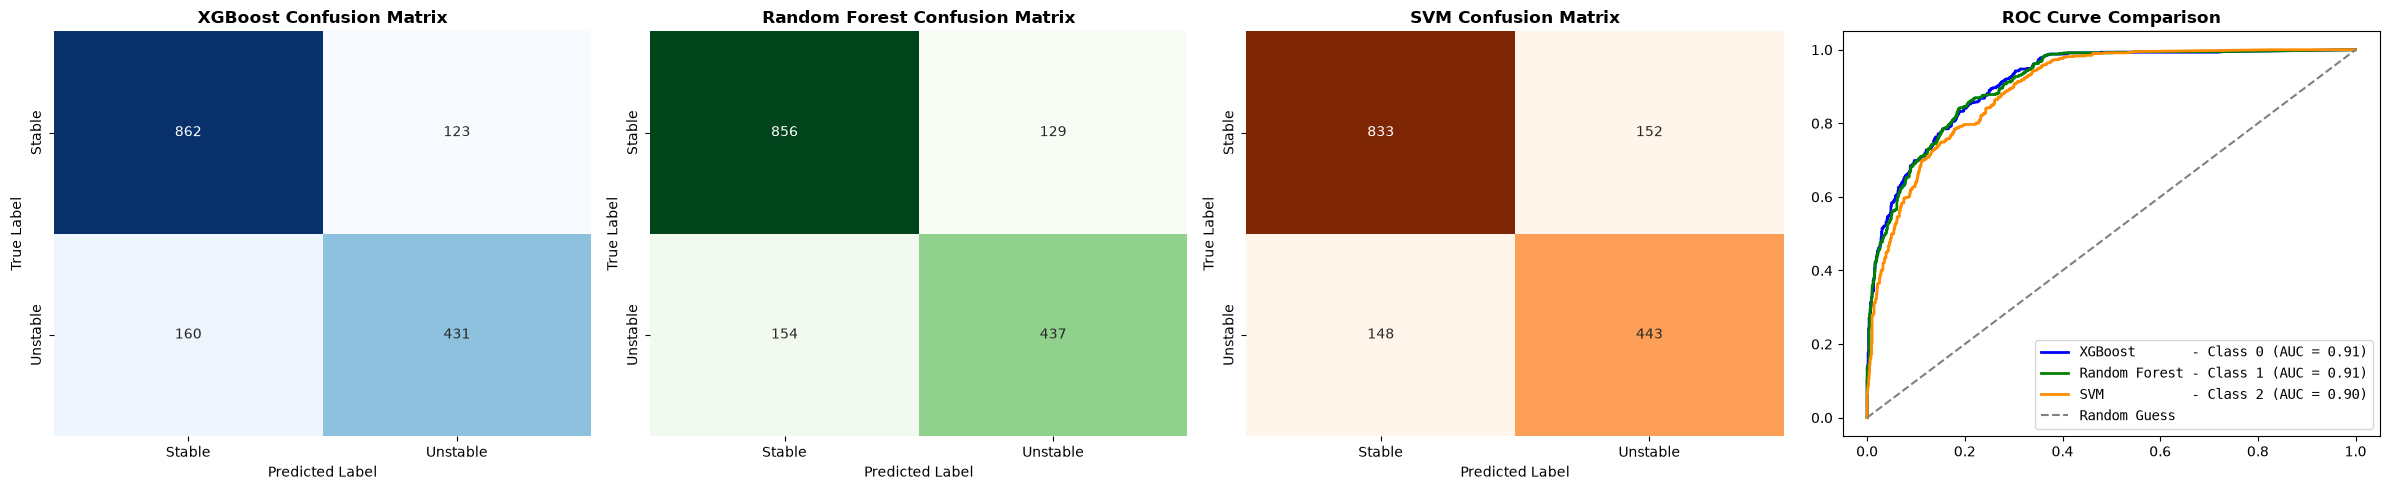

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 4, figsize=(24, 5), dpi=100)

# Plot 1: XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
            xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, 
            xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
axes[1].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Plot 3: SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False,
            xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
axes[2].set_title('SVM Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

# Plot 4: ROC Curve Comparison
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
axes[3].plot(fpr_xgb, tpr_xgb, label=f'XGBoost       - Class 0 (AUC = {auc(fpr_xgb, tpr_xgb):.2f})', color='blue', lw=2)
axes[3].plot(fpr_rf, tpr_rf, label=f'Random Forest - Class 1 (AUC = {auc(fpr_rf, tpr_rf):.2f})', color='green', lw=2)
axes[3].plot(fpr_svm, tpr_svm, label=f'SVM           - Class 2 (AUC = {auc(fpr_svm, tpr_svm):.2f})', color='darkorange', lw=2)
axes[3].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
axes[3].set_title('ROC Curve Comparison', fontweight='bold')
axes[3].legend(loc="lower right", prop={'family': 'monospace'})

plt.tight_layout()
plt.show()

## 💾 Step 6: Model Serialization
We export the XGBoost model, the Random Forest model, the SVM model, and the `StandardScaler` needed for the SVM inference pathway.

In [18]:
import joblib
import os

os.makedirs('MachineLearning/models', exist_ok=True)
joblib.dump(scaler, 'MachineLearning/models/input_scaler.joblib')
joblib.dump(xgb_model, 'MachineLearning/models/xgboost_risk_model.joblib')
joblib.dump(rf_model, 'MachineLearning/models/rf_risk_model.joblib')
joblib.dump(svm_model, 'MachineLearning/models/svm_risk_model.joblib')
joblib.dump(feature_cols, 'MachineLearning/models/feature_columns.joblib')
print("Exported input_scaler, xgboost, random_forest, svm, and feature_columns to /models/")

Exported input_scaler, xgboost, random_forest, svm, and feature_columns to /models/
